In [ ]:
#| default_exp learner

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, Path('../').resolve().as_posix())

In [ ]:
sys.path

['/app/data/deeplearning/course22p2_zh',
 '/usr/local/lib/python312.zip',
 '/usr/local/lib/python3.12',
 '/usr/local/lib/python3.12/lib-dynload',
 '/app/data/.local/lib/python3.12/site-packages',
 '/app/data/.local/share/pyskills',
 '/usr/local/lib/python3.12/site-packages']

In [ ]:
#|export
import math,torch,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from operator import attrgetter
from functools import partial
from copy import copy

from torch import optim
import torch.nn.functional as F

from miniai.conv import *

from fastprogress import progress_bar,master_bar

In [ ]:
import matplotlib as mpl
import torchvision.transforms.functional as TF
from contextlib import contextmanager
from torch import nn,tensor
from datasets import load_dataset,load_dataset_builder
from miniai.datasets import *
from miniai.conv import *
import logging
from fastcore.test import test_close

In [ ]:
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

In [ ]:
logging.disable(logging.WARNING)

## Learner

In [ ]:
x,y = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

In [ ]:
inplace??


````python
def inplace(f):
    def _f(b):
        f(b)
        return b
    return _f
````

**File:** `~/deeplearning/course22p2_zh/miniai/datasets.py`

In [ ]:
@inplace
def transformi(b): b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]

In [ ]:
bs = 1024
tds = dsd.with_transform(transformi)

In [ ]:
dls = DataLoaders.from_dd(tds, bs, num_workers=4)
dt = dls.train
xb,yb = next(iter(dt))
xb.shape,yb[:10]

(torch.Size([1024, 784]), tensor([5, 4, 9, 4, 3, 0, 6, 5, 7, 6]))

In [ ]:
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func=optim.SGD): fc.store_attr()

    def one_batch(self):
        self.xb,self.yb = to_device(self.batch)
        self.preds = self.model(self.xb)
        self.loss = self.loss_func(self.preds, self.yb)
        if self.model.training:
            self.loss.backward()
            self.opt.step()
            self.opt.zero_grad()
        with torch.no_grad(): self.calc_stats()

    def calc_stats(self):
        acc = (self.preds.argmax(dim=1)==self.yb).float().sum()
        self.accs.append(acc)
        n = len(self.xb)
        self.losses.append(self.loss*n)
        self.ns.append(n)

    def one_epoch(self, train):
        self.model.training = train
        dl = self.dls.train if train else self.dls.valid
        for self.num,self.batch in enumerate(dl): self.one_batch()
        n = sum(self.ns)
        print(self.epoch, self.model.training, sum(self.losses).item()/n, sum(self.accs).item()/n)
    
    def fit(self, n_epochs):
        self.accs,self.losses,self.ns = [],[],[]
        self.model.to(def_device)
        self.opt = self.opt_func(self.model.parameters(), self.lr)
        self.n_epochs = n_epochs
        for self.epoch in range(n_epochs):
            self.one_epoch(True)
            with torch.no_grad(): self.one_epoch(False)

In [ ]:
m,nh = 28*28,50
model = nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))

In [ ]:
learn = Learner(model, dls, F.cross_entropy, lr=0.2)
learn.fit(1)

0 True 1.1753061197916668 0.5986166666666667


0 False 1.120378125 0.6133857142857143


## Basic Callbacks Learner

In [ ]:
#|export
class CancelFitException(Exception): pass
class CancelBatchException(Exception): pass
class CancelEpochException(Exception): pass

In [ ]:
#|export
class Callback(): order = 0

In [ ]:
#|export
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)

In [ ]:
class CompletionCB(Callback):
    def before_fit(self, learn): self.count = 0
    def after_batch(self, learn): self.count += 1
    def after_fit(self, learn): print(f'Completed {self.count} batches')

In [ ]:
cbs = [CompletionCB()]
run_cbs(cbs, 'before_fit')
run_cbs(cbs, 'after_batch')
run_cbs(cbs, 'after_fit')

Completed 1 batches


In [ ]:
class SayHelloCB(Callback):
    def before_fit(self, learn): print('morning')
    def after_batch(self, learn): print('afternoon')
    def after_fit(self, learn): print('evening')

In [ ]:
cbs = [SayHelloCB()]
run_cbs(cbs, 'before_fit')
run_cbs(cbs, 'after_batch')
run_cbs(cbs, 'after_fit')

morning
afternoon
evening


In [ ]:
class Learner():
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD): fc.store_attr()

    def one_batch(self):
        self.preds = self.model(self.batch[0])
        self.loss = self.loss_func(self.preds, self.batch[1])
        if self.model.training:
            self.loss.backward()
            self.opt.step()
            self.opt.zero_grad()

    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        try:
            self.callback('before_epoch')
            for self.iter,self.batch in enumerate(self.dl):
                try:
                    self.callback('before_batch')
                    self.one_batch()
                    self.callback('after_batch')
                except CancelBatchException: pass
            self.callback('after_epoch')
        except CancelEpochException: pass
    
    def fit(self, n_epochs):
        self.n_epochs = n_epochs
        self.epochs = range(n_epochs)
        self.opt = self.opt_func(self.model.parameters(), self.lr)
        try:
            self.callback('before_fit')
            for self.epoch in self.epochs:
                self.one_epoch(True)
                self.one_epoch(False)
            self.callback('after_fit')
        except CancelFitException: pass

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)

In [ ]:
m,nh = 28*28,50
def get_model(): return nn.Sequential(nn.Linear(m,nh), nn.ReLU(), nn.Linear(nh,10))

In [ ]:
model = get_model()
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[CompletionCB()])
learn.fit(1)

Completed 64 batches


In [ ]:
#| export
class SingleBatchCB(Callback):
    order = 1
    def after_batch(self, learn): raise CancelFitException()

In [ ]:
learn = Learner(get_model(), dls, F.cross_entropy, lr=0.2, cbs=[SingleBatchCB(), CompletionCB()])
learn.fit(1)

## Metrics

In [ ]:
class Metric:
    def __init__(self): self.reset()
    def reset(self): self.vals,self.ns = [],[]
    def add(self, inp, targ=None, n=1):
        self.last = self.calc(inp, targ)
        self.vals.append(self.last)
        self.ns.append(n)
    @property
    def value(self):
        ns = tensor(self.ns)
        return (tensor(self.vals)*ns).sum()/ns.sum()
    def calc(self, inps, targs): return inps

In [ ]:
class Accuracy(Metric):
    def calc(self, inps, targs): return (inps==targs).float().mean()

In [ ]:
acc = Accuracy()
acc.add(tensor([0, 1, 2, 0, 1, 2]), tensor([0, 1, 1, 2, 1, 0]))
acc.add(tensor([1, 1, 2, 0, 1]), tensor([0, 1, 1, 2, 1]))
acc.value

tensor(0.45)

In [ ]:
acc.ns

[1, 1]

实际使用时n是不是应该传批次大小

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好眼力！你说得很对。在实际训练中，最后一个 batch 的大小往往和其他 batch 不同（因为数据集大小可能不能被批次大小整除），所以应该用**批次大小**作为 `n` 传入，这样计算加权平均时才准确。

比如你看到的那段测试代码：

```python
acc.add(tensor([0, 1, 2, 0, 1, 2]), tensor([0, 1, 1, 2, 1, 0]))  # 6个样本
acc.add(tensor([1, 1, 2, 0, 1]), tensor([0, 1, 1, 2, 1]))        # 5个样本
```

这里两个 `add` 都用了默认的 `n=1`，所以算出来的 `value` 是把两个 batch 的平均准确率简单平均了（各占50%权重），而不是按样本数量加权平均。

在后面的 `Learner` 代码中你也会看到，`one_batch` 里调用 metric 时，应该传 `len(self.xb)` 作为 `n`。要自己改一下试试吗？

<details class='token-usage-details' markdown='1'><summary>$0.0028</summary>

`total=12,289 | in=11,430 | out=859 | cached=0.0% | reasoning=611 | searches=0 | $0.0028`

</details>


In [ ]:
loss = Metric()
loss.add(0.6, n=32)
loss.add(0.9, n=2)
loss.value, round((0.6*32+0.9*2)/(32+2), 2)

(tensor(0.62), 0.62)

## Some callbacks

In [ ]:
# !pip install torcheval

In [ ]:
#|export
from torcheval.metrics import MulticlassAccuracy,Mean

In [ ]:
metric = MulticlassAccuracy()
metric.update(tensor([0, 2, 1, 3]), tensor([0, 1, 2, 3]))
metric.compute()

tensor(0.50)

In [ ]:
metric.reset()
metric.compute()

tensor(nan)

In [ ]:
#|export
def to_cpu(x):
    if isinstance(x, Mapping): return {k:to_cpu(v) for k,v in x.items()}
    if isinstance(x, list): return [to_cpu(o) for o in x]
    if isinstance(x, tuple): return tuple(to_cpu(list(x)))
    res = x.detach().cpu()
    return res.float() if res.dtype==torch.float16 else res

为什么float16要转成float

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！`float16`（半精度）在 GPU 上训练时很常用——能节省显存、加速计算。但把它移到 CPU 上之后，很多 CPU 上的操作（比如打印、计算指标、可视化）并不原生支持 `float16`，容易出现精度问题或报错。

所以 `to_cpu` 在把 tensor 搬到 CPU 时，顺手把 `float16` 转成 `float32`，保证后续处理不会出问题。而其他 dtype（如 `float32`, `int64` 等）在 CPU 上兼容性很好，就不需要转了。

<details class='token-usage-details' markdown='1'><summary>$0.0024</summary>

`total=12,776 | in=12,410 | out=366 | cached=12.4% | reasoning=235 | searches=0 | $0.0024`

</details>


In [ ]:
#|export
class MetricsCB(Callback):
    def __init__(self, *ms, **metrics):
        for o in ms: metrics[type(o).__name__] = o
        self.metrics = metrics
        self.all_metrics = copy(metrics)
        self.all_metrics['loss'] = self.loss = Mean()

    def _log(self, d): print(d)
    def before_fit(self, learn): learn.metrics = self
    def before_epoch(self, learn): [o.reset() for o in self.all_metrics.values()]

    def after_epoch(self, learn):
        log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
        log['epoch'] = learn.epoch
        log['train'] = 'train' if learn.model.training else 'eval'
        self._log(log)

    def after_batch(self, learn):
        x,y,*_ = to_cpu(learn.batch)
        for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
        self.loss.update(to_cpu(learn.loss), weight=len(x))

In [ ]:
#|export
class DeviceCB(Callback):
    def __init__(self, device=def_device): fc.store_attr()
    def before_fit(self, learn):
        if hasattr(learn.model, 'to'): learn.model.to(self.device)
    def before_batch(self, learn): learn.batch = to_device(learn.batch, device=self.device)

In [ ]:
model = get_model()
metrics = MetricsCB(accuracy=MulticlassAccuracy())
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[DeviceCB(), metrics])
learn.fit(1)

{'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}


{'accuracy': '0.700', 'loss': '0.847', 'epoch': 0, 'train': 'eval'}


## Flexible learner

In [ ]:
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs)
        fc.store_attr()

    @contextmanager
    def cb_ctx(self, nm):
        try:
            self.callback(f'before_{nm}')
            yield
            self.callback(f'after_{nm}')
        except globals()[f'Cancel{nm.title()}Exception']: pass
        finally: self.callback(f'cleanup_{nm}')
                
    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        with self.cb_ctx('epoch'):
            for self.iter,self.batch in enumerate(self.dl):
                with self.cb_ctx('batch'):
                    self.predict()
                    self.get_loss()
                    if self.training:
                        self.backward()
                        self.step()
                        self.zero_grad()
    
    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        # `add_cb` and `rm_cb` were added in lesson 18
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            self.opt = self.opt_func(self.model.parameters(), self.lr if lr is None else lr)
            with self.cb_ctx('fit'):
                for self.epoch in self.epochs:
                    if train: self.one_epoch(True)
                    if valid: torch.no_grad()(self.one_epoch)(False)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs)
        fc.store_attr()

    cbs会影响函数外吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这里有两个层面可以看：

**1. 参数 `cbs` 本身**

在 `__init__` 里写 `cbs = fc.L(cbs)` —— 这只是给局部变量 `cbs` 重新赋值，不会改变函数外部传入的那个变量。Python 的参数传递是"传引用"，但重新绑定局部变量不会影响外面。

**2. `self.cbs`（即 `fc.L(cbs)`）与原来的列表的关系**

`fc.L(cbs)` 会创建一个新的 `L` 对象，里面的元素还是原来那些 callback 对象的引用。所以如果外面传进来的是：

```python
my_cbs = [cb1, cb2]
learn = Learner(model, dls, cbs=my_cbs)
```

那么 `self.cbs` 是一个新的 `L` 对象，**不是** `my_cbs` 本身。后面在 `fit()` 里 `self.cbs.append(cb)` 只是修改 `self.cbs`，不会动 `my_cbs`。

但要注意：`cb1`、`cb2` 这些 callback **对象本身**是共享的，如果 callback 内部有可变状态（比如 `MetricsCB` 里的 `self.metrics`），那外面还是会受影响。

简单总结：**`self.cbs` 这个列表不会被外部影响，但里面的 callback 对象是共享的。**

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=14,611 | in=13,784 | out=827 | cached=99.4% | reasoning=529 | searches=0 | $0.0004`

</details>


cbs = fc.L(cbs)
那么cbs=fc.L(cbs)的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`fc.L()` 是 fastcore 里的一个实用函数，它的作用是**把输入统一包装成一个 `L` 对象**（L 是 fastcore 对 list 的增强版）。

关键特性：

- 如果 `cbs=None`，`fc.L(None)` → 空的 `L()`
- 如果 `cbs=[cb1, cb2]`，`fc.L([cb1, cb2])` → 新的 `L([cb1, cb2])`
- 如果 `cbs=cb1`（单个对象），`fc.L(cb1)` → `L([cb1])`

换句话说，这一行的作用是**把各种可能的输入形式（None、单个 callback、列表等）统一标准化**，这样后面遍历 `self.cbs` 时就不用做各种类型判断了。

<details class='token-usage-details' markdown='1'><summary>$0.0002</summary>

`total=14,567 | in=14,157 | out=410 | cached=99.5% | reasoning=233 | searches=0 | $0.0002`

</details>


但是这里并没有存self.cbs啊 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

你说得对，这里确实没有显式写 `self.cbs = cbs`，而是靠 `fc.store_attr()` 自动保存的。

`fc.store_attr()` 会**捕获当前函数的所有局部变量**，然后帮你存到 `self` 上。所以这一行：

```python
cbs = fc.L(cbs)
fc.store_attr()
```

等价于：

```python
cbs = fc.L(cbs)
self.model = model
self.dls = dls
self.loss_func = loss_func
self.lr = lr
self.cbs = cbs       # ← 这里，存的是标准化后的 L 对象
self.opt_func = opt_func
```

`cbs` 是 `__init__` 里的局部变量，`store_attr()` 自然也会把它存为 `self.cbs`。

<details class='token-usage-details' markdown='1'><summary>$0.0004</summary>

`total=14,782 | in=14,397 | out=385 | cached=93.4% | reasoning=201 | searches=0 | $0.0004`

</details>


In [ ]:
#|export
class TrainCB(Callback):
    def __init__(self, n_inp=1): self.n_inp = n_inp
    def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])
    def get_loss(self, learn): learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
    def backward(self, learn): learn.loss.backward()
    def step(self, learn): learn.opt.step()
    def zero_grad(self, learn): learn.opt.zero_grad()

NB: I added `self.n_inp` after the lesson. This allows us to train models with more than one input or output.

In [ ]:
#|export
class ProgressCB(Callback):
    order = MetricsCB.order+1
    def __init__(self, plot=False): self.plot = plot
    def before_fit(self, learn):
        learn.epochs = self.mbar = master_bar(learn.epochs)
        self.first = True
        if hasattr(learn, 'metrics'): learn.metrics._log = self._log
        self.losses = []
        self.val_losses = []

    def _log(self, d):
        if self.first:
            self.mbar.write(list(d), table=True)
            self.first = False
        self.mbar.write(list(d.values()), table=True)

    def before_epoch(self, learn): learn.dl = progress_bar(learn.dl, leave=False, parent=self.mbar)
    def after_batch(self, learn):
        learn.dl.comment = f'{learn.loss:.3f}'
        if self.plot and hasattr(learn, 'metrics') and learn.training:
            self.losses.append(learn.loss.item())
            if self.val_losses: self.mbar.update_graph([[fc.L.range(self.losses), self.losses],[fc.L.range(learn.epoch).map(lambda x: (x+1)*len(learn.dls.train)), self.val_losses]])
    
    def after_epoch(self, learn): 
        if not learn.training:
            if self.plot and hasattr(learn, 'metrics'): 
                self.val_losses.append(learn.metrics.all_metrics['loss'].compute())
                self.mbar.update_graph([[fc.L.range(self.losses), self.losses],[fc.L.range(learn.epoch+1).map(lambda x: (x+1)*len(learn.dls.train)), self.val_losses]])

NB: Added validation loss plotting after the lesson.

In [ ]:
model = get_model()

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

accuracy,loss,epoch,train
0.596,1.167,0,train
0.729,0.794,0,eval
0.743,0.710,1,train
0.764,0.654,1,eval


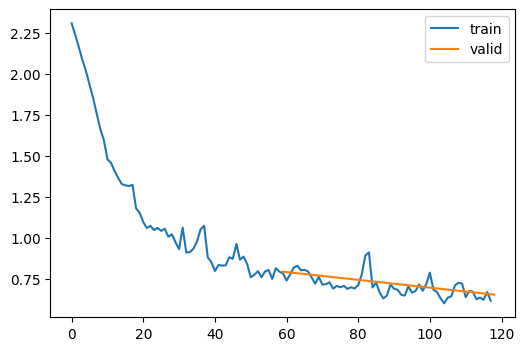

In [ ]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(2)

## Updated versions since the lesson

After the lesson we noticed that `contextlib.context_manager` has a surprising "feature" which doesn't let us raise an exception before the `yield`. Therefore we've replaced the context manager with a decorator in this updated version of `Learner`. We have also added a few more callbacks in `one_epoch()`.

In [ ]:
#|export
class with_cbs:
    def __init__(self, nm): self.nm = nm
    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs)
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']: pass
            finally: o.callback(f'cleanup_{self.nm}')
        return _f

In [ ]:
#|export
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs)
        fc.store_attr()

    @with_cbs('batch')
    def _one_batch(self):
        self.predict()
        self.callback('after_predict')
        self.get_loss()
        self.callback('after_loss')
        if self.training:
            self.backward()
            self.callback('after_backward')
            self.step()
            self.callback('after_step')
            self.zero_grad()

    @with_cbs('epoch')
    def _one_epoch(self):
        for self.iter,self.batch in enumerate(self.dl): self._one_batch()

    def one_epoch(self, training):
        self.model.train(training)
        self.dl = self.dls.train if training else self.dls.valid
        self._one_epoch()

    @with_cbs('fit')
    def _fit(self, train, valid):
        for self.epoch in self.epochs:
            if train: self.one_epoch(True)
            if valid: torch.no_grad()(self.one_epoch)(False)

    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        # `add_cb` and `rm_cb` were added in lesson 18
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            if lr is None: lr = self.lr
            if self.opt_func: self.opt = self.opt_func(self.model.parameters(), lr)
            self._fit(train, valid)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

accuracy,loss,epoch,train
0.606,1.176,0,train
0.702,0.796,0,eval


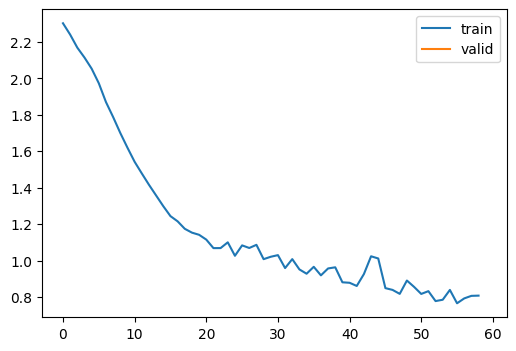

In [ ]:
model = get_model()

metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(1)

## TrainLearner and MomentumLearner

In [ ]:
#|export
class TrainLearner(Learner):
    def predict(self): self.preds = self.model(self.batch[0])
    def get_loss(self): self.loss = self.loss_func(self.preds, self.batch[1])
    def backward(self): self.loss.backward()
    def step(self): self.opt.step()
    def zero_grad(self): self.opt.zero_grad()

In [ ]:
#|export
class MomentumLearner(TrainLearner):
    def __init__(self, model, dls, loss_func, lr=None, cbs=None, opt_func=optim.SGD, mom=0.85):
        self.mom = mom
        super().__init__(model, dls, loss_func, lr, cbs, opt_func)

    def zero_grad(self):
        with torch.no_grad():
            for p in self.model.parameters(): p.grad *= self.mom

accuracy,loss,epoch,train
0.674,0.976,0,train
0.789,0.588,0,eval


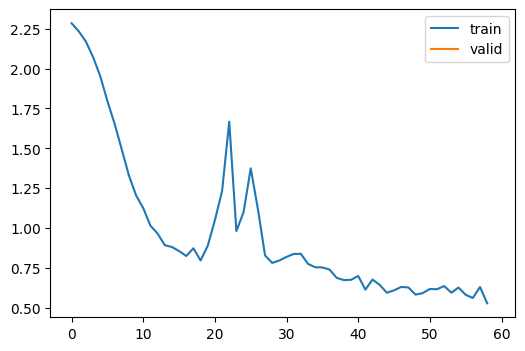

In [ ]:
# NB: No TrainCB
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [DeviceCB(), metrics, ProgressCB(plot=True)]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=0.1, cbs=cbs)
learn.fit(1)

## LRFinderCB

In [ ]:
class LRFinderCB(Callback):
    def __init__(self, lr_mult=1.3): fc.store_attr()
    
    def before_fit(self, learn):
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if loss > self.min*3: raise CancelFitException()
        for g in learn.opt.param_groups: g['lr'] *= self.lr_mult

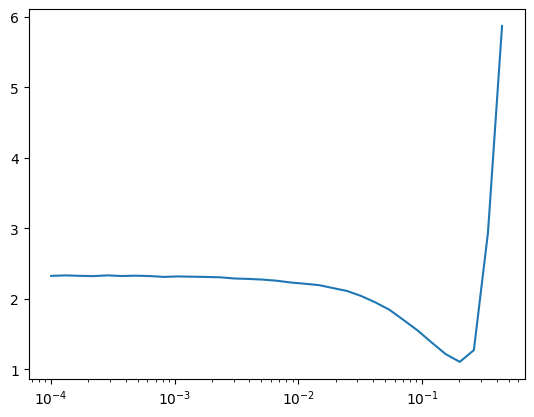

In [ ]:
lrfind = LRFinderCB()
cbs = [DeviceCB(), lrfind]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1e-4, cbs=cbs)
learn.fit(1)
plt.plot(lrfind.lrs, lrfind.losses)
plt.xscale('log')

In [ ]:
#|export
from torch.optim.lr_scheduler import *

[ExponentialLR](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html#torch.optim.lr_scheduler.ExponentialLR)

什么是学习率调度器

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！学习率调度器就是**在训练过程中动态调整学习率**的工具。

回顾一下，学习率（learning rate）控制着每次参数更新迈多大的步子：

- 学习率太大 → 可能跳过最优点，震荡不收敛
- 学习率太小 → 收敛太慢，浪费时间

学习率调度器的思路是：**一开始大踏步往前走，到后面小步慢走，精调参数**。

比如 `ExponentialLR`，它每过一个 epoch 就把学习率乘以一个系数（比如 0.9），让学习率随时间指数衰减：

```
lr = 0.2 → 0.18 → 0.162 → 0.146 → ...
```

这样就达到了"先快后慢"的效果，往往能比固定学习率得到更好的结果。

你想看看具体怎么用 `ExponentialLR` 吗？或者想了解其他常见的调度策略（比如阶梯式衰减、余弦退火）？

<details class='token-usage-details' markdown='1'><summary>$0.0036</summary>

`total=18,305 | in=18,069 | out=236 | cached=8.5% | reasoning=36 | searches=0 | $0.0036`

</details>


为什么LinearLR是从小到大

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这是因为 `LinearLR` 的默认用途是**热身（warmup）**。

你之前的直觉是"先大后小"没错——那是训练**中后期**的策略。但**刚开始训练时**情况有点特殊：

- 模型参数刚随机初始化完，完全是"懵"的状态
- 这时梯度方向很不靠谱，如果用太大学习率，参数容易被一脚踹飞，训练直接炸了
- 所以先用小学习率让模型"慢慢热身"几个 batch/epoch，等参数稳定一点了，再把学习率加到目标值

因此 `LinearLR` 的默认行为（`start_factor=1/3` 线性增加到 `end_factor=1.0`）就是做 warmup 用的。

**完整的调度策略往往是：先 warmup 升 → 再 decay 降。**

想看看怎么把 `LinearLR` 和 `ExponentialLR` 组合起来用吗？

<details class='token-usage-details' markdown='1'><summary>$0.0024</summary>

`total=18,833 | in=18,331 | out=502 | cached=41.9% | reasoning=303 | searches=0 | $0.0024`

</details>


哪些调度器是warmup，哪些是中后期策略

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

简单的分法：

**Warmup（从低到高）**
- `LinearLR` — 线性升
- `ConstantLR` — 先保持一个低学习率一段时间

**中后期衰减（从高到低）**
- `ExponentialLR` — 指数衰减，每轮乘一个系数
- `StepLR` / `MultiStepLR` — 阶梯式下降
- `CosineAnnealingLR` — 余弦曲线平滑下降
- `ReduceLROnPlateau` — 验证集指标不涨了才降（自适应）

**两个都包含的**
- `OneCycleLR` — 先 warmup 升到峰值，再余弦衰减到底
- `CosineAnnealingWarmRestarts` — 余弦衰减后跳回高学习率再衰减（重复周期）

有没有哪个你想具体看看怎么用？

<details class='token-usage-details' markdown='1'><summary>$0.0024</summary>

`total=18,971 | in=18,597 | out=374 | cached=41.3% | reasoning=191 | searches=0 | $0.0024`

</details>


In [ ]:
#|export
class LRFinderCB(Callback):
    def __init__(self, gamma=1.3, max_mult=3): fc.store_attr()
    
    def before_fit(self, learn):
        self.sched = ExponentialLR(learn.opt, self.gamma)
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if math.isnan(loss) or (loss > self.min*self.max_mult):
            raise CancelFitException()
        self.sched.step()

    def cleanup_fit(self, learn):
        plt.plot(self.lrs, self.losses)
        plt.xscale('log')

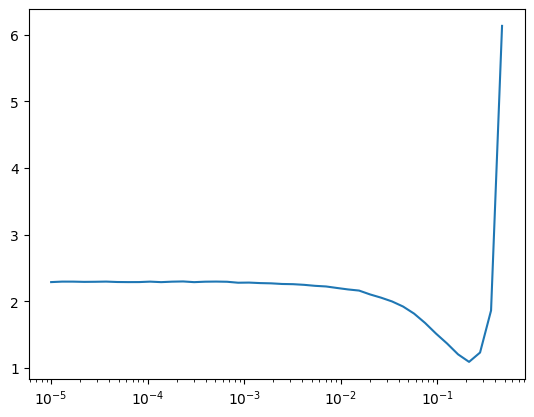

In [ ]:
cbs = [DeviceCB()]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1e-5, cbs=cbs)
learn.fit(3, cbs=LRFinderCB())

In [ ]:
#|export
class LinearLRFinderCB(Callback):
    def __init__(self, max_mult=3): fc.store_attr()
    
    def before_fit(self, learn):
        self.sched = LinearLR(learn.opt, 0.001, 1, total_iters=learn.n_epochs*50)
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if math.isnan(loss) or (loss > self.min*self.max_mult):
            raise CancelFitException()
        self.sched.step()

    def cleanup_fit(self, learn):
        plt.plot(self.lrs, self.losses)
        # plt.xscale('log')

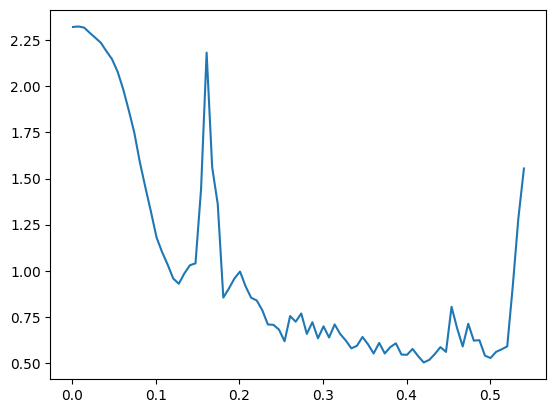

In [ ]:
cbs = [DeviceCB()]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1, cbs=cbs)
learn.fit(3, cbs=LinearLRFinderCB(max_mult=3))

total_iters要怎么设置

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`total_iters` 是 `LinearLR` 走完全程需要的**步数**——这里的"步"就是 batch，不是 epoch。

在 `LinearLRFinderCB` 的上下文里：

```python
self.sched = LinearLR(learn.opt, total_iters=learn.n_epochs*100)
```

`learn.n_epochs*100` 的意思是：如果 `n_epochs=3`，那就用 300 个 batch 把学习率 `lr=1` 从 `1 * 1/3 ≈ 0.33` 线性升到 `1`（因为默认 `start_factor=1/3`）。300 个 batch 之后学习率就不会再变了，后面的 epoch 保持最高学习率直到 stop 条件触发。

**实际应用中怎么设？**

这取决于你跑一个 epoch 有多少个 batch。比如你的 `DataLoader` 有 500 个 batch：

- 想扫 1 个 epoch → `total_iters=500`
- 想扫 2 个 epoch → `total_iters=1000`
- 想扫半个 epoch → `total_iters=250`

`n_epochs*100` 只是一种粗略写法，假设每个 epoch 大约 100 个 batch。你需要根据 `len(dl)` 来精确设置。

你要不要算一下当前数据集一个 epoch 有多少个 batch？

<details class='token-usage-details' markdown='1'><summary>$0.0027</summary>

`total=20,304 | in=19,839 | out=465 | cached=38.7% | reasoning=167 | searches=0 | $0.0027`

</details>


In [ ]:
#|export
@fc.patch
def lr_find(self:Learner, gamma=1.3, max_mult=3, start_lr=1e-5, max_epochs=10):
    self.fit(max_epochs, lr=start_lr, cbs=LRFinderCB(gamma=gamma, max_mult=max_mult))

`lr_find` was added in lesson 18. It's just a shorter way of using `LRFinderCB`.

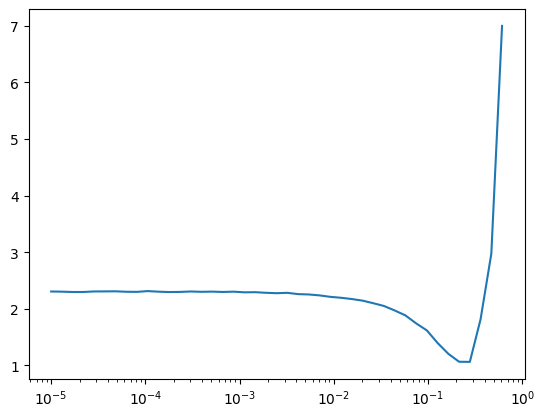

In [ ]:
MomentumLearner(get_model(), dls, F.cross_entropy, cbs=cbs).lr_find()

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()

/home/tmabraham/anaconda3/envs/course22p2/lib/python3.10/site-packages/nbdev/export.py:54: UserWarning: Notebook '/home/tmabraham/course22p2/nbs/horse2zebra-latents_AB.ipynb' uses `#|export` without `#|default_exp` cell.
Note nbdev2 no longer supports nbdev1 syntax. Run `nbdev_migrate` to upgrade.
See https://nbdev.fast.ai/getting_started.html for more information.
  warn(f"Notebook '{nbname}' uses `#|export` without `#|default_exp` cell.\n"
/home/tmabraham/anaconda3/envs/course22p2/lib/python3.10/site-packages/nbdev/export.py:54: UserWarning: Notebook '/home/tmabraham/course22p2/nbs/FIBItoHE-latents_AB.ipynb' uses `#|export` without `#|default_exp` cell.
Note nbdev2 no longer supports nbdev1 syntax. Run `nbdev_migrate` to upgrade.
See https://nbdev.fast.ai/getting_started.html for more information.
  warn(f"Notebook '{nbname}' uses `#|export` without `#|default_exp` cell.\n"
